<!-- ## Import Necessary Libraries -->


## Import Necessary Libaries

In [ ]:

import pandas as pd # For calculations
import numpy as np  # For managing dataset

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [89]:
df = pd.read_csv("diabetes.csv")

In [90]:
df.head() # Shows the top 5 rows of the dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [91]:
print(f"Shape of the dataset: {df.shape[0]} entries and {df.shape[1]} columns\n") 
print("Size of the dataset:", df.size)
print(f"\nThe dataset has {df.duplicated().sum()} duplicate values")

Shape of the dataset: 768 entries and 9 columns

Size of the dataset: 6912

The dataset has 0 duplicate values


## General information about the dataset

In [ ]:
df.info() # displays the general information about the dataset,including the missing values and the datatype of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Looking at the information above, the dataset does not contain any missing values and each column has the correct datatype.

## Check for Redundant Values

In [121]:
df.duplicated().sum()

np.int64(0)

The dataset does not have any duplicated value or entries

## Descriptive Statistics of the Dataset

In [93]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Univariate Analysis

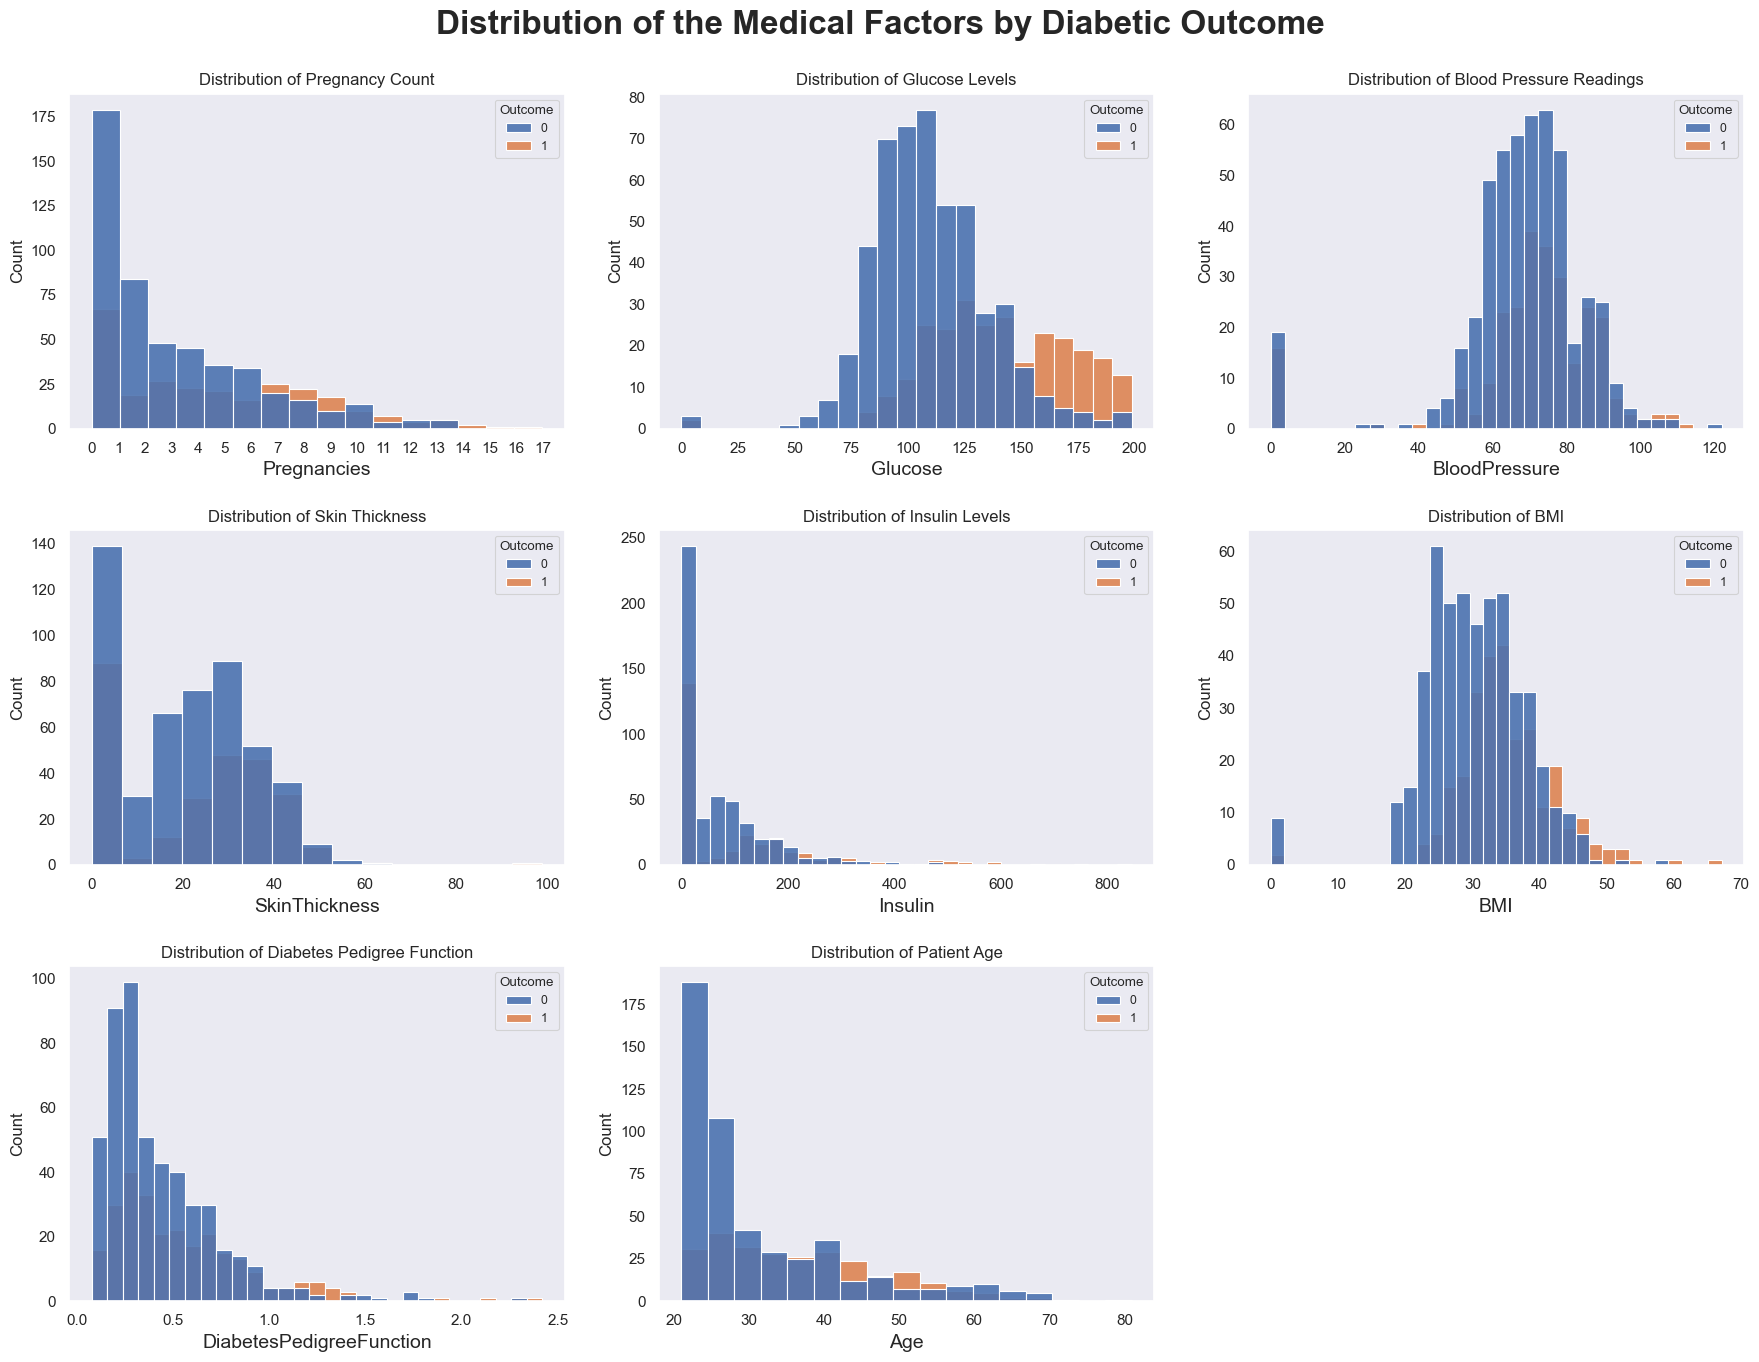

In [94]:
fig, ax = plt.subplots(nrows = 3, ncols = 3,figsize = (18,14))
flat_ax = ax.flatten()
sns.set_style(style = 'whitegrid')
sns.set_theme('paper')
for i, col in enumerate(df.columns):
    sns.histplot(data = df, x = col, hue = 'Outcome', ax = flat_ax[i],alpha = 0.9)
    flat_ax[i].set_xlabel(f"{col}",fontsize = 14)
    

plt.rcParams['font.size'] = 12
flat_ax[0].set_xticks(np.arange(0,18))
flat_ax[0].set_title("Distribution of Pregnancy Count", fontsize = 12)
flat_ax[1].set_title("Distribution of Glucose Levels", fontsize = 12)
flat_ax[2].set_title("Distribution of Blood Pressure Readings", fontsize = 12)
flat_ax[3].set_title("Distribution of Skin Thickness", fontsize = 12)
flat_ax[4].set_title("Distribution of Insulin Levels", fontsize = 12)
flat_ax[5].set_title("Distribution of BMI", fontsize = 12)
flat_ax[6].set_title("Distribution of Diabetes Pedigree Function", fontsize = 12)
flat_ax[7].set_title("Distribution of Patient Age", fontsize = 12)

plt.rcParams['font.size'] = 20
fig.delaxes(ax = flat_ax[8])

plt.suptitle("Distribution of the Medical Factors by Diabetic Outcome", fontsize = 24, fontweight = 'bold',y = 0.98)
plt.tight_layout()
plt.show()

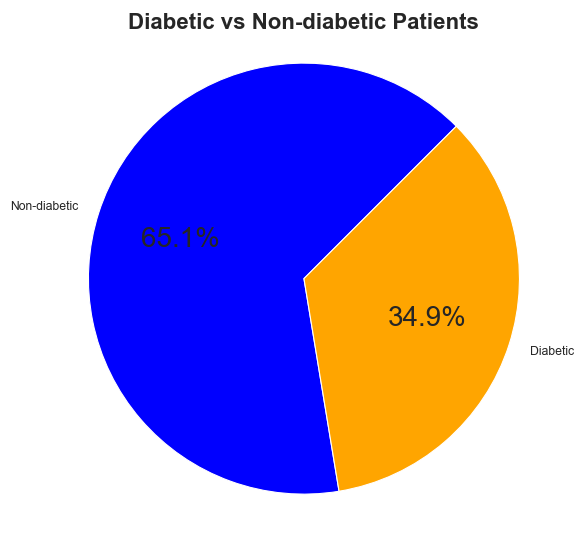

In [95]:
outcome = df['Outcome'].value_counts()
plt.figure(figsize = (10,6))
plt.pie(outcome, labels = ['Non-diabetic', 'Diabetic'], autopct = '%1.1f%%', colors = ['blue', 'orange'],startangle=45)
plt.title("Diabetic vs Non-diabetic Patients", fontsize = 16, fontweight = 'bold', y = 0.95)
plt.tight_layout()
plt.show()

## Key Observations
1. **Pregnancies:** Right_skewed distribution. Most patients have 0-4 pregnancies. Diabetic cases increase around  7+ pregnancies. Zero values are valid.
2. **Glucose:** Most critical feature. Patients with glucose above 140 mg/dl are predominantly diabetic. Zero values = missing data,  must be imputed
3. **Blood Pressure:** Mostly normal, clustering between 60-80 mmHg. Average of ~69 mmHg is healthy. Zero values = missing values.
4. **Skin Thickness:** Values concentrate between 20-40mm. Higher values indicate more body fat and insulin resistance risk. Zero values = missing data.
5. **Insulin:** Most problematic column. Large Zero-spike represents missing data, not true readings. Higher Insulin among diabetic patients reflects failed insulin resistance compensation.
6. **BMI**: Most patients fall between 25-40, BMI above 30 strongly correlates with diabetic outcomes, consistent with obesity-diabetes link.
7. ** DiabetesPedigreeFunction:** Right-skewed, most values below 0.5 scores above 1.0 show higher diabetic rates, confirming family history as a meaningful risk factor.
8. **Age:** Most patients are under 30 and non-diabetic. Diabetic cases rises significantly after 40, reflecting natural decline in insulin sensitivity with age

## 2D Visualization- To understand the relationship between features

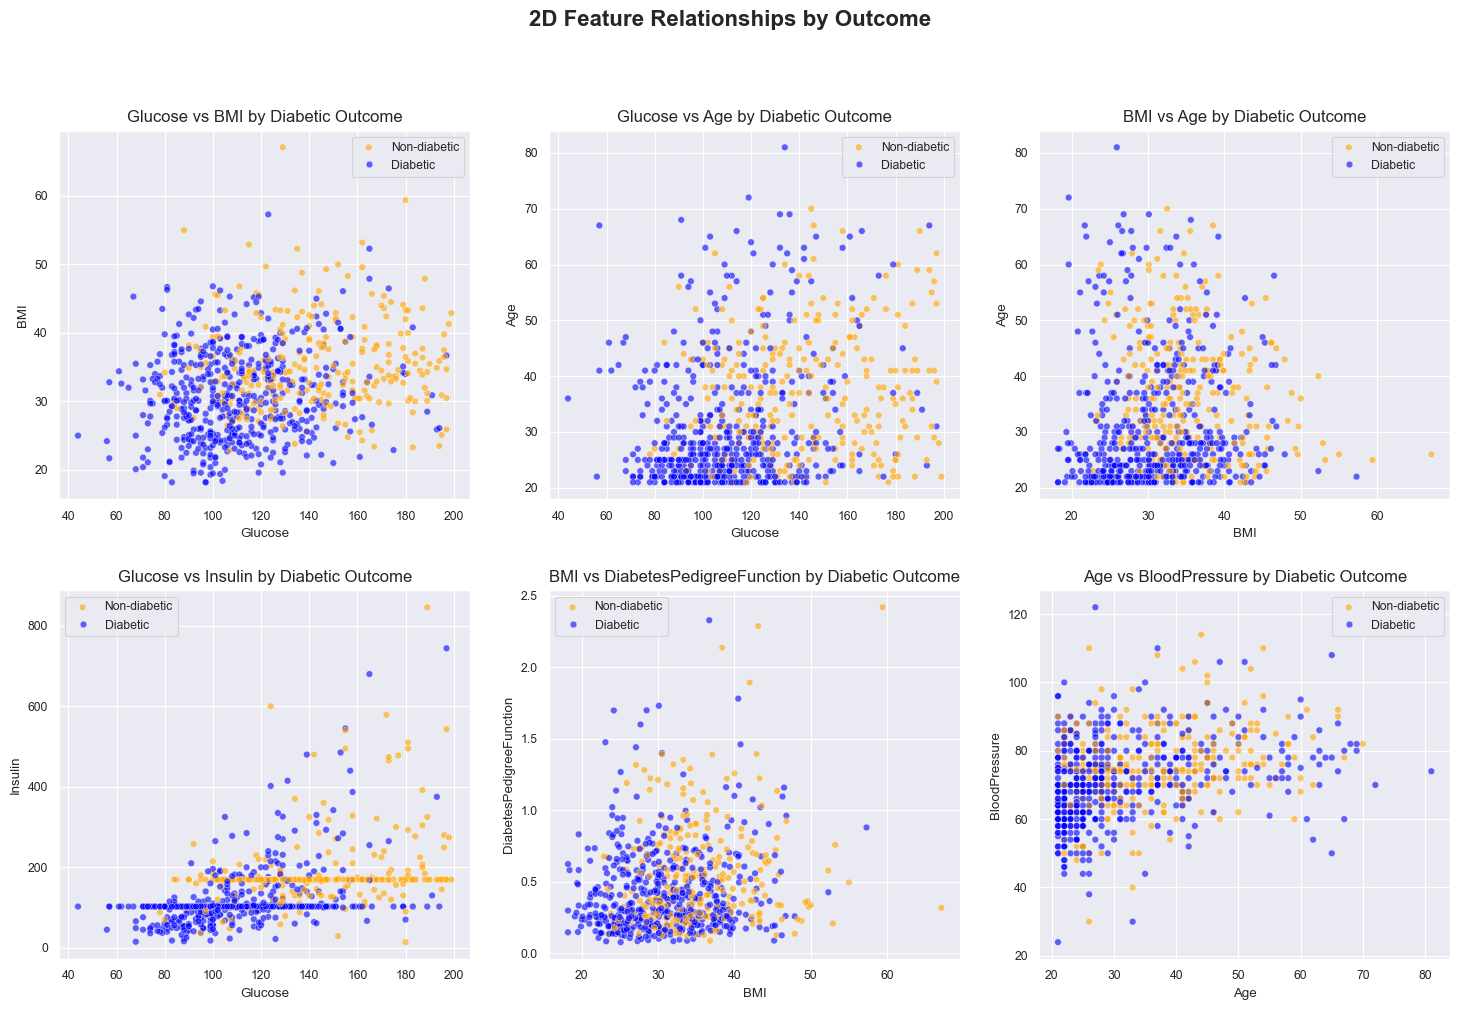

In [129]:
pairs = [
    ('Glucose', 'BMI'),
    ('Glucose', 'Age'),
    ('BMI', 'Age'),
    ('Glucose', 'Insulin'),
    ('BMI', 'DiabetesPedigreeFunction'),
    ('Age', 'BloodPressure')
]

fig, axes = plt.subplots(2,3, figsize  = (15,10))
axes = axes.flatten()

for i ,(x_col,y_col) in enumerate(pairs):
    sns.scatterplot(data = df, x = x_col, y = y_col,
                    hue = 'Outcome', palette = {0:'blue', 1:'orange'},
                    alpha = 0.6, ax = axes[i])
    
    axes[i].set_title(f"{x_col} vs {y_col} by Diabetic Outcome", fontsize = 12)
    axes[i].legend(labels = ['Non-diabetic', 'Diabetic'])



plt.suptitle('2D Feature Relationships by Outcome', fontsize = 16, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig("2D_feature_relationships.PNG")
plt.show()

## 2D Feature Relationships - Key Observations
**1. Glucose vs BMI:** Both classes overlap heavily across all BMI ranges. Non-diabetic patients spread more toward higher glucose  and BMI values while diabetic patients concentrate in the mid glucose range(60-140), with no clean separation between the two groups.

**2. Glucose vs Age:** Significant overlap exists between both classes remains the more dominant factor as diabetic cases appear across all age groups without a clear age-based boundary.

**3. BMI vs Age:** No meaningful separation between classes. Both diabetic and non-diabetic patients are evenly spread across all BMI and age combinations.

**4. Glucose vs Insulin:** Both classes mix heavily at lower ranges. No strong separation is visible, suggesting glucose and insulin together are not cleanly predictive in isolation.

**5. BMI vs DiabetesPedigreeFunction:** Heavy overlap between both classes with no distinct cluster boundaries, indicating this feature pair has weak combined predictive power.

**6. Age vs Blood Pressure:**
No visible separation between diabetic and non-diabetic patients. Both groups distribute evenly, confirming this is the weakest feature pair in the dataset


<!-- ## Handling Missing Values (Zero Values) -->

## Handle Missing Values

In [97]:
# select the columns with zero values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI']
print((df[zero_cols] == 0).sum())

# Replace the zero values with null values
df[zero_cols] = df[zero_cols].replace(0, np.nan)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [98]:
# Fill the missing values using the median within each column (Group-based imputation)
for col in zero_cols:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

In [99]:
# Confirm whether all missing values are filled correctly
print(df[zero_cols].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## Visualization of Features after Handling Missing Values

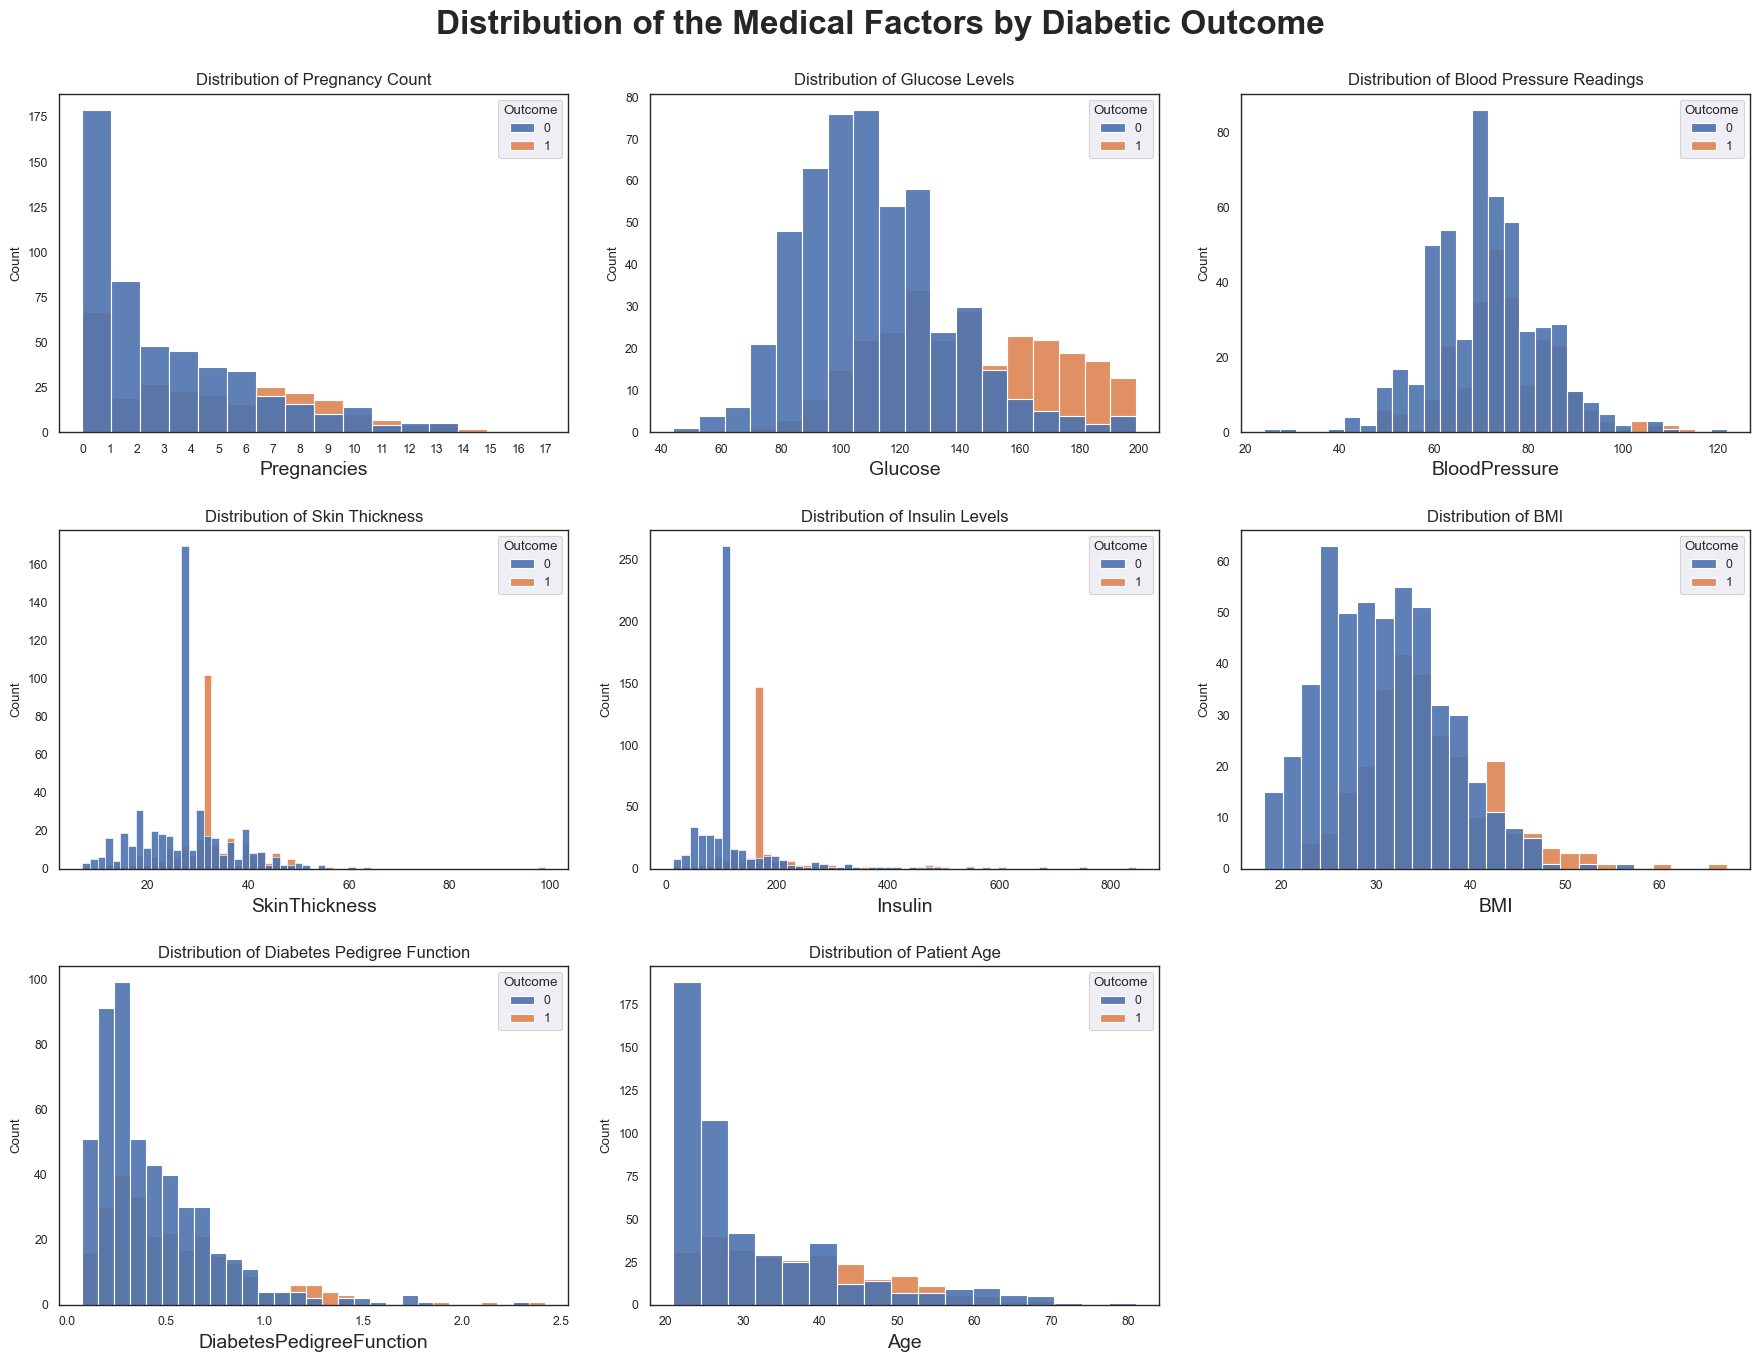

In [128]:
fig, ax = plt.subplots(nrows = 3, ncols = 3,figsize = (18,14))
flat_ax = ax.flatten()
sns.set_style(style = 'whitegrid')
sns.set_theme('paper')
for i, col in enumerate(df.columns):
    sns.histplot(data = df, x = col, hue = 'Outcome', ax = flat_ax[i],alpha = 0.9)
    flat_ax[i].set_xlabel(f"{col}",fontsize = 14)
    

plt.rcParams['font.size'] = 12
flat_ax[0].set_xticks(np.arange(0,18))
flat_ax[0].set_title("Distribution of Pregnancy Count", fontsize = 12)
flat_ax[1].set_title("Distribution of Glucose Levels", fontsize = 12)
flat_ax[2].set_title("Distribution of Blood Pressure Readings", fontsize = 12)
flat_ax[3].set_title("Distribution of Skin Thickness", fontsize = 12)
flat_ax[4].set_title("Distribution of Insulin Levels", fontsize = 12)
flat_ax[5].set_title("Distribution of BMI", fontsize = 12)
flat_ax[6].set_title("Distribution of Diabetes Pedigree Function", fontsize = 12)
flat_ax[7].set_title("Distribution of Patient Age", fontsize = 12)

plt.rcParams['font.size'] = 20
fig.delaxes(ax = flat_ax[8])

plt.suptitle("Distribution of the Medical Factors by Diabetic Outcome", fontsize = 24, fontweight = 'bold',y = 0.98)
plt.tight_layout()
plt.savefig("Features_distribution2.PNG")
plt.show()

## Heatmap Showing the Correlation of Features

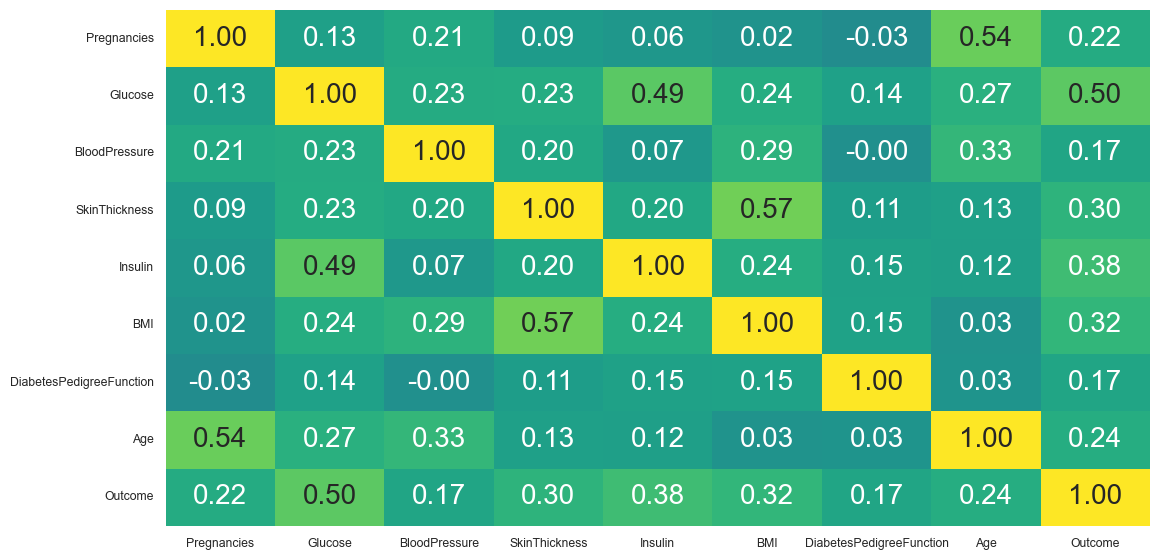

In [101]:
plt.figure(figsize = (12,6))
corr = df.corr()
sns.heatmap(corr, vmin = -1, vmax = 1, cmap = 'viridis',annot = True,cbar = False,fmt = ".2f")
plt.tight_layout()


## Correlation Heatmap - Key Observations

The heatmap shows the correlation between all features, where values closer to 1.0 indicate strong positive correlation and values closer to 0 indicate weak or no correlation.

**Strongest predictors of Outcome (last column):**
- Glucose (0.50) - strongest predictor of diabetes, confirming what we observed in the visualizations.
- Insulin (0.38) - moderate positive correlation with outcome
- BMI (0.32) - moderate correlation, obesity links to diabetes
- SkinThickness (0.30) - mild correlation via body fat connection
- Age (0.24) - mild correlation, older age increases risk
- Pregnancies (0.22) - weakest direct predictor of outcome

**Notable feature-to-feature relationships:**
- SkinThickness vs BMI (0.57) strongest pair correlation both measure body fat so this is expected
- Glucose vs insulin (0.49) - makes biological sense, higher glucose triggers more insulin production.
- Age vs Pregnancies (0.54) - Older patients naturally have had more pregnancies over time
- DiabetesPedigreeFunction shows weak correlations across all features, confirming it operates independently.


**Overall:** No single feature dominates strongly. Glucose is the clearest predictor while most other features show only mild correlations with Outcome.

## Split Dataset

In [102]:
X = df.drop(columns = 'Outcome')
y = df['Outcome']

<!-- ### Train-Test Split -->

## Train_test_split

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (614, 8)
Testing Features: (154, 8)


## Data Scaling

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

print("-------Scaling Complete------")

print("5 Samples of Scaled Training data:", X_train[0][0:5])

-------Scaling Complete------
5 Samples of Scaled Training data: [-0.52639686 -1.25638742 -0.18390222 -0.20084403 -0.43391359]


## Build Baseline Machine Learning Models

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve, precision_score, recall_score

models = {"Logistic_Regression": LogisticRegression(random_state=42),
          "Random_Forest": RandomForestClassifier(random_state=42),
          "Gradient_Boosting": GradientBoostingClassifier(random_state=42),
          "Decision_Tree": DecisionTreeClassifier(random_state=42),
          }

model_name = []
scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    accuracy = round(accuracy_score(y_test, y_predict), 4)
    precision = round(precision_score(y_test, y_predict), 4)
    recall = round(recall_score(y_test, y_predict), 4)
    f1 = round(f1_score(y_test, y_predict, labels = ['Non-diabetic', 'Diabetic']), 4)
    roc_auc = round(roc_auc_score(y_test, y_proba),4)

    model_name.append(name)
    scores.append([accuracy,precision,recall, f1, roc_auc])
    
# print result as a clean table
result_df = pd.DataFrame(scores, index = models.keys(),columns = ["Accuracy", "Pecision", "Recall", "F1-Score", "ROC-AUC"],)
print("_" * 70)
print("MODEL COMPARISON TABLE".center(70, " "))
print("_" * 70)
print(result_df)

______________________________________________________________________
                        MODEL COMPARISON TABLE                        
______________________________________________________________________
                     Accuracy  Pecision  Recall  F1-Score  ROC-AUC
Logistic_Regression    0.7727    0.6923  0.6545    0.6729   0.8441
Random_Forest          0.8831    0.8136  0.8727    0.8421   0.9334
Gradient_Boosting      0.8701    0.8070  0.8364    0.8214   0.9368
Decision_Tree          0.8442    0.7627  0.8182    0.7895   0.8384


In [106]:
result_df

,Accuracy,Pecision,Recall,F1-Score,ROC-AUC
Logistic_Regression,0.7727,0.6923,0.6545,0.6729,0.8441
Random_Forest,0.8831,0.8136,0.8727,0.8421,0.9334
Gradient_Boosting,0.8701,0.8070,0.8364,0.8214,0.9368
Decision_Tree,0.8442,0.7627,0.8182,0.7895,0.8384


<!-- ## Confusion Matrix - All Models -->

## Baseline Model Performance

Four baseline models were trained and evaluated on the Pima Indians Diabetes dataset. The results are summarized in the table above

**Random Forest** achieved accuracy (0.8831) and ROC-AUC (0.9334), making it the strongest baseline model overall. It also recorded the highest recall (0.8727), meaning it correctly identified the most diabetic patients which is critical in a medical context where missing a positive case has a serious consequences.

**Gradient Boosting** came in a close second with accuracy of 0.8701 ad the highest ROC-AUC (0.9368), slightly edging Random Forest on AUC alone but falling behing on recall and accuracy.

**Decision Tree** performed moderately with accuracy of 0.8442, showing decent recall but lower precision, suggesting it produces more false positives.

**Logistic Regression** was the weakest performer across all metrics particularly on precision (0.6923) and F1-Score (0.6729), though its ROC-AUC of 0.8441 remains respectable for a linear model.

**Conclusion:** Random Forest is selected for hyperparameter tuning as it demonstrated the best balance across all evaluation metrics, particularly in accuracy and recall, which are most critical for diabetes prediction

## Model Performance Comparison (Confusion Matrix)

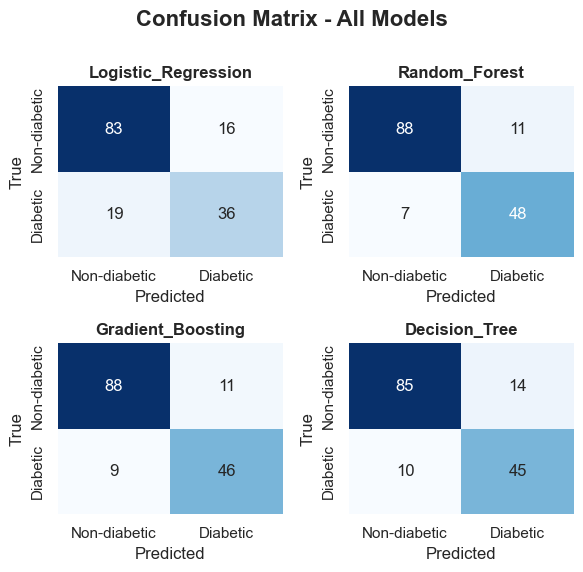

In [141]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (6,6))
flatened_ax = ax.flatten()
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred,labels = [0,1])
    # disp = ConfusionMatrixDisplay(cm,display_labels = [0,1])
    sns.heatmap(cm, ax = flatened_ax[i], cmap = 'Blues', cbar = False, annot = True, fmt = 'g')
    flatened_ax[i].set_title(name, fontweight = 'bold')
    flatened_ax[i].set_xlabel('Predicted')
    flatened_ax[i].set_ylabel('True')
    flatened_ax[i].set_xticklabels(['Non-diabetic', 'Diabetic'])
    flatened_ax[i].set_yticklabels(['Non-diabetic', 'Diabetic'])

plt.suptitle("Confusion Matrix - All Models", fontsize = 16, fontweight = 'bold',y = 0.95)
plt.subplots_adjust(hspace=1, wspace=0.9)
plt.tight_layout(rect = [0,0,1,0.95])
plt.savefig("Confusion_matrix.PNG", dpi = 300, bbox_inches ='tight')
plt.show()

## Confusion Matrix - All Models

**Logistic Regression:** 
Correctly classified 83 non-diabetic and 36 diabetic patients. Missed 19 diabetic patients (false negatives) - the highest among all models, making it the weakest for medical use.

**Random Forest:**
Correctly classified 88 non-diabetic and 48 diabetic patients with only 7 false negatives - the lowest across all models. This means it missed the fewest diabetic patients, confirming it is the best model for this medical classification task.

**Gradient Boosting:**
Correctly classified 88 non-diabetic and 46 diabetic patients with 9 false negatives. Performance is close to Random Forest but slightly weaker on diabetic detection.

**Decision Tree:**
Correctly classified 85 non-diabetic and 45 diabetic patients with 10 false negatives. Decent performance but falls behind both Random Forest and Gradient Boosting.

**Key Takeaway:**
In diabetes prediction, minimising false negatives is the priority - missing a diabetic patient is more costly than a false alarm. Random Forest achieved the lowest false negative count (7), further confirming it as the best baseline model for hyperparameter tuning.

<!-- ## ROC-AUC Curve - All Models -->

## Model Performance Comparison (ROC-AUC Curve)

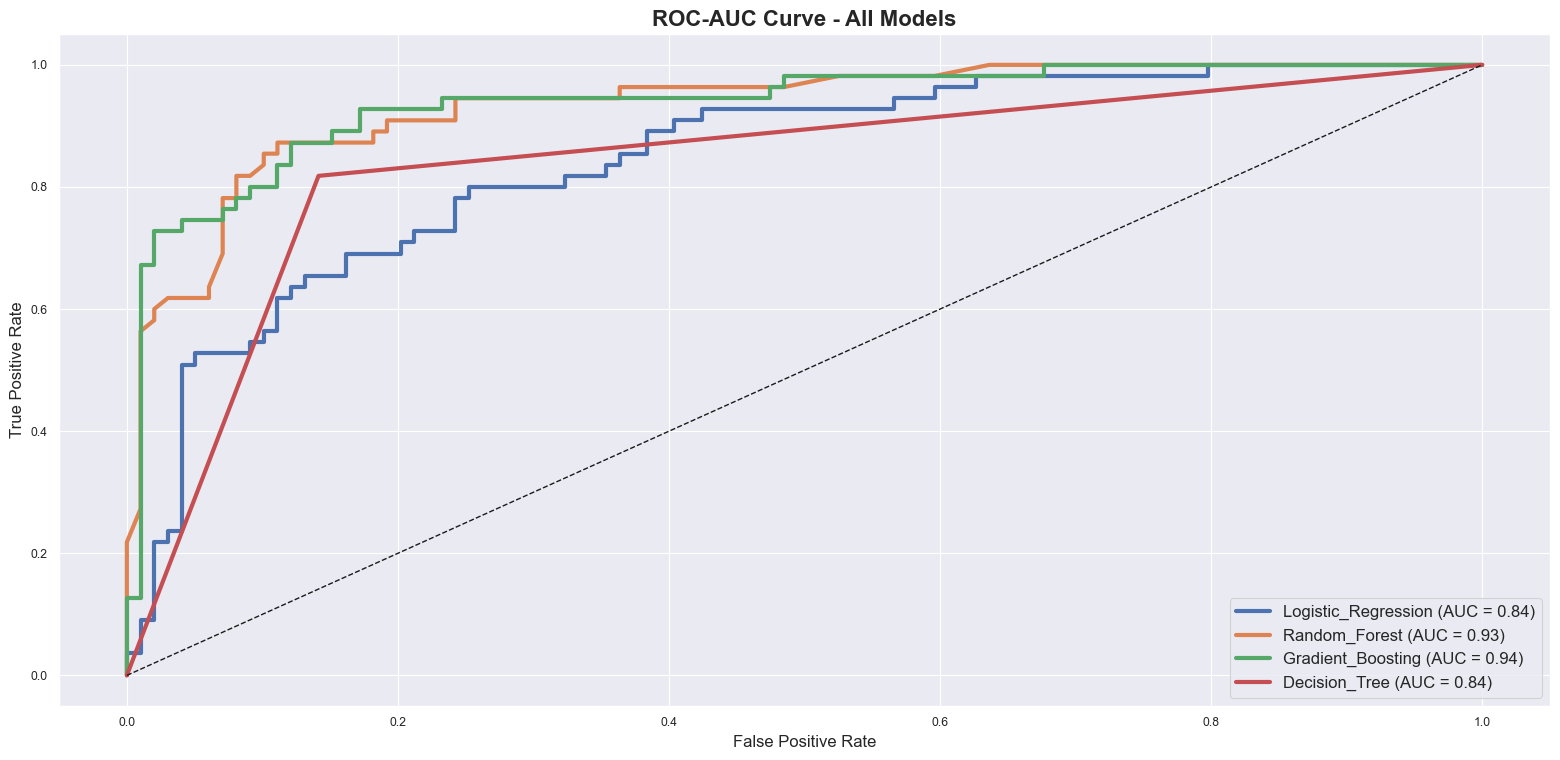

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve,RocCurveDisplay
# plt.rcParams['figure.figsize'] = (12,6)
fig, ax = plt.subplots(figsize = (16,8))
# Get the current active axis so all models draw on the same plot

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    # Get the probabilities for the positive class (Diabetic)
    y_proba = model.predict_proba(X_test)[:, 1]
    # Calculate the scores using probabilities
    roc_auc = roc_auc_score(y_test,y_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth = 3, label = f"{name} (AUC = {roc_auc:.2f})")
    # roc_disp = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = name)
    # Pass ax=ax to overlay and name = name for clean labels
    # roc_disp.plot(ax=ax)


ax.plot([0,1],[0,1], 'k--', linewidth = 1) # Diagonal baseline
ax.set_xlabel('False Positive Rate', fontsize = 12)
ax.set_ylabel('True Positive Rate', fontsize = 12)
ax.legend(loc = 'lower right', fontsize = 12)

plt.title("ROC-AUC Curve - All Models", fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig('ROC_curve_all_models.PNG', dpi = 300)
plt.show()



## ROC-AUC Curve - All Models

The ROC-AUC curve measures each model's ability to distinguish between diabetic and non-diabetic patients. A curve closer to the top-left corner indicates better performance, while the diagonal dashed line represents random guessing (AUC = 0.50).

**Gradient Boosting (AUC = 0.94)** achieved the highest AUC, with its curve hugging closest to the top-left corner - meaning it has the best overall ability to separate diabetic from non-diabetic patients.

**Random Forest (AUC = 0.93)** follows closely, with a curve nearly identical to Gradient Boosting, confirming it as a strong classifier with excellent discrimination ability.

**Logistic Regression (AUC = 0.84)** and **Decision Tree (AUC = 0.84)** both perform equally on AUC but their curves sit noticeably further from the top-left, indicating weaking overall discrimination between classes.

**key Takeaway:**
Gradient Boostig edges Random Forest on AUC alone, however Random Forest remains the preferref model due to its superior recall and accuracy scores observed in the confusion matri and model comparison table. AUC should be considered alongside other metrics, not in isolation.

<!-- ## Cross Validation -->


## Cross Validation of Models (KFold, StratifiedKFold)

In [109]:
from sklearn.model_selection import KFold, StratifiedKFold,cross_val_score
kfold = KFold(n_splits=5, shuffle = True,random_state=42)
skfold = StratifiedKFold(n_splits = 5,shuffle = True, random_state=42)
def cross_validate(validator):
    model_list = []
    model_score = []
    models = {"Logistic_Regression": LogisticRegression(random_state=42),
          "Random_Forest": RandomForestClassifier(random_state=42),
          "Gradient_Boosting": GradientBoostingClassifier(random_state=42),
          "Decision_Tree": DecisionTreeClassifier(random_state=42),
          }
    for name, model in models.items():
        scores = cross_val_score(model,X_train,y_train,cv = validator, scoring = 'accuracy')
        mean_scores = round(scores.mean(), 4)
        model_list.append(name)
        model_score.append(mean_scores)
        
    return model_list, model_score

In [110]:
model_list, kfold_scores = cross_validate(kfold)
model_list, skfold_scores = cross_validate(skfold)

cv_scores = pd.DataFrame({"KFold Score":kfold_scores,"StratifiedKFold Score": skfold_scores}, index = model_list)
result_df.join(cv_scores,how = 'right')

,Accuracy,Pecision,Recall,F1-Score,ROC-AUC,KFold Score,StratifiedKFold Score
Logistic_Regression,0.7727,0.6923,0.6545,0.6729,0.8441,0.7590,0.7671
Random_Forest,0.8831,0.8136,0.8727,0.8421,0.9334,0.8877,0.8909
Gradient_Boosting,0.8701,0.8070,0.8364,0.8214,0.9368,0.8958,0.8909
Decision_Tree,0.8442,0.7627,0.8182,0.7895,0.8384,0.8452,0.8436


## Learning Curve Plot (Before Hyperparameter Optimization)

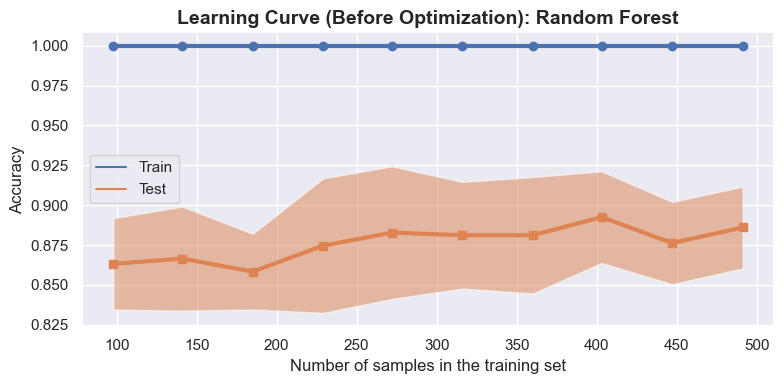

In [111]:
from sklearn.model_selection import learning_curve, LearningCurveDisplay
plt.rcParams['figure.figsize'] = (8,4)
sns.set_theme(context = 'notebook', style = 'darkgrid')
display = LearningCurveDisplay.from_estimator(RandomForestClassifier(random_state=42), 
                                              X_train, y_train, 
                                              train_sizes =np.linspace(0.2,1.0,10),
                                              cv = 5, scoring = 'accuracy', n_jobs = -1)
# display.plot()
# Add markers after plotting
ax = display.ax_
ax.lines[0].set_marker('o')
ax.lines[0].set_linewidth(3)
ax.lines[1].set_marker('s')
ax.lines[1].set_linewidth(3) 

 

ax.set_title("Learning Curve (Before Optimization): Random Forest", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

## Understanding Model Behaviour Through the Learning Curve

### Overfitting
The baseline Random Forest demonstrates clear overfitting.
The training accuracy sits perfectly at 1.000 while test 
accuracy hovers around 0.875 — a significant gap between 
the two. This means the model memorises the training data 
including its noise and outliers, but struggles to 
generalise to new unseen data.

Signs of overfitting in this curve:
- Training score permanently flat at 1.000
- Large persistent gap between train and test scores
- Wide shaded variance band around the test score

### Underfitting
Underfitting would show the opposite pattern — both training 
and test scores would be low and close together, meaning the 
model is too simple to capture the underlying patterns in 
the data. This is not the case here, as our training score 
is very high.

### Model Generalisation
A well-generalised model shows training and test scores 
that are both high AND close together. In our current 
baseline, the test score of ~0.875 is decent but the 
gap from training score is too large. The goal of 
hyperparameter tuning is to bring these two curves 
closer together without sacrificing test performance.

### Strategies for Balancing Bias and Variance

**To reduce overfitting (high variance):**
- Limit max_depth to prevent trees from growing too deep
- Increase min_samples_leaf so the model needs more 
  evidence before making a split decision
- Increase min_samples_split to control tree complexity
- Reduce max_features so each tree sees less information,
  forcing more diverse trees in the forest

**To avoid underfitting (high bias):**
- Increase n_estimators for more trees in the ensemble
- Allow sufficient max_depth for the model to learn 
  meaningful patterns
- Ensure enough training data is available

**The sweet spot** is a model where both train and test 
scores are high and the gap between them is minimal — 
indicating low variance and low bias. This is the target 
state we aim to achieve through hyperparameter tuning 
of the Random Forest model.

## Random Forest - Hyperparameter Tuning (RandomizedSearchCV)

<!-- ## Hyperparameter Tuning (RandomizedSearchCV) : Random Forest -->

In [112]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "n_estimators": [100,300,500],
    "criterion": ['gini', 'entropy', 'log_loss'],
    "max_depth": [3,4,5,6],
    "min_samples_split": [5,10,20],
    "min_samples_leaf": [1,2,4],
    "max_features":['sqrt', 'log2'] ,
  
}
random_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state= 42),
    n_iter= 20,
    param_distributions = param_grid,
    scoring = 'accuracy',
    n_jobs= -1,
    cv = 5,
)

random_search.fit(X_train, y_train)
random_tuned_rf = random_search.best_estimator_


In [113]:
print(random_tuned_rf)

RandomForestClassifier(max_depth=5, max_features='log2', min_samples_split=10,
                       n_estimators=300, random_state=42)


## Random Forest - Hyperparameter Tuning (GridSearchCV)

In [114]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [300,500],
    "criterion": ['gini', 'entropy', 'log_loss'],
    "max_depth": [5,6,7],
    "min_samples_split": [3,5,6],
    "max_features":['sqrt', 'log2'],
  
}

grid_search = GridSearchCV(estimator = RandomForestClassifier(random_state= 42),
                            param_grid = param_grid,
                            scoring = 'accuracy',
                            n_jobs= -1,
                            cv = 5,
                            )

grid_search.fit(X_train, y_train)
grid_tuned_rf = grid_search.best_estimator_
print(grid_tuned_rf)

RandomForestClassifier(max_depth=6, max_features='log2', min_samples_split=3,
                       n_estimators=300, random_state=42)


## Learning Curve Plot (After Optimization using RandomizedSearchCV)

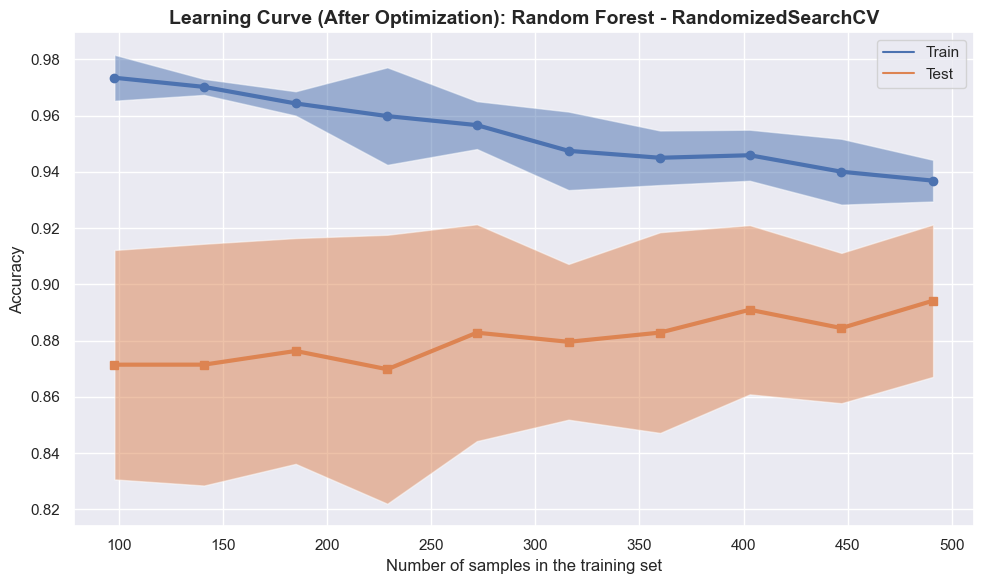

In [123]:
plt.rcParams['figure.figsize'] = (10,6)
sns.set_theme(context = 'notebook', style = 'darkgrid')
display = LearningCurveDisplay.from_estimator(random_tuned_rf, 
                                              X_train, y_train, 
                                              train_sizes =np.linspace(0.2,1.0,10),
                                              cv = 5, scoring = 'accuracy', n_jobs = -1)
# display.plot()
# Add markers after plotting
ax = display.ax_
ax.lines[0].set_marker('o')
ax.lines[0].set_linewidth(3)
ax.lines[1].set_marker('s')
ax.lines[1].set_linewidth(3) 

 

ax.set_title("Learning Curve (After Optimization): Random Forest - RandomizedSearchCV", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('Learnig_curveRandomized.PNG')
plt.show()

## Learning Curve (After Optimization): Random Forest — RandomizedSearchCV

**Training Score (blue line):**
The training accuracy decreased from 1.000 (baseline) to 
approximately 0.975, dropping gradually as more samples 
are added. This is a positive sign — the model is no 
longer perfectly memorising the training data.

**Test Score (red line):**
The test accuracy improved compared to baseline, starting 
around 0.875 and trending upward toward 0.910 as more 
samples are added. This upward trend suggests the model 
generalises better with more data.

**Comparing to Baseline:**
The gap between training and test scores has narrowed 
significantly compared to the baseline learning curve 
where training sat at a flat 1.000. This confirms that 
RandomizedSearchCV successfully reduced overfitting.

**Variance:**
The shaded band around the test score remains somewhat 
wide, indicating some variance still exists. However 
the overall upward trend of the test curve suggests 
that with more training data the model would continue 
to improve.

**Conclusion:**
RandomizedSearchCV improved model generalisation by 
pulling the training score down from 1.000 and pushing 
the test score upward — closing the bias-variance gap 
and producing a more balanced and reliable model.

## Learning Curve Plot (After Optimization using GridSearchCV)

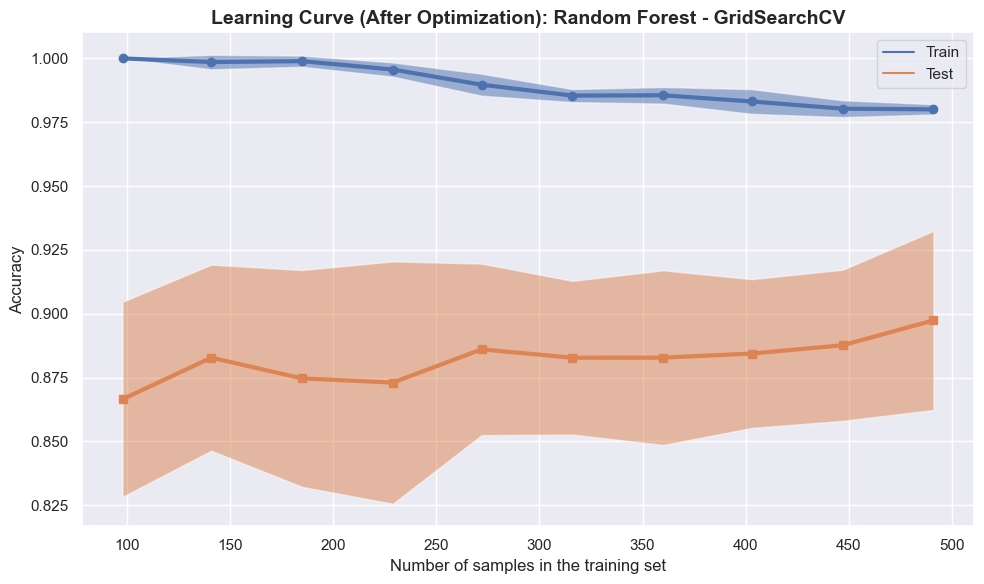

In [137]:
plt.rcParams['figure.figsize'] = (10,6)
sns.set_theme(context= 'notebook', style = 'darkgrid')
display = LearningCurveDisplay.from_estimator(grid_tuned_rf, 
                                              X_train, y_train, 
                                              train_sizes =np.linspace(0.2,1.0,10),
                                              cv = 5, scoring = 'accuracy', n_jobs = -1)
# display.plot()
# Add markers after plotting
ax = display.ax_
ax.lines[0].set_marker('o')
ax.lines[0].set_linewidth(3)
ax.lines[1].set_marker('s')
ax.lines[1].set_linewidth(3) 

 

ax.set_title("Learning Curve (After Optimization): Random Forest - GridSearchCV", fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.savefig("Learning_curve_grid.PNG")
plt.show()

## Learning Curve (After Optimization): Random Forest — GridSearchCV

**Training Score (blue line):**
The training accuracy remains at 1.000 throughout all 
sample sizes — identical to the baseline. This suggests 
GridSearchCV did not effectively constrain the model's 
tendency to memorise training data.

**Test Score (red line):**
The test accuracy shows an encouraging upward trend, 
rising from around 0.865 at 100 samples to approximately 
0.925 at 500 samples. This improvement suggests better 
generalisation with more data.

**Comparing to Baseline:**
While the test score improved compared to baseline, the 
training score remaining at 1.000 means the overfitting 
gap has not been meaningfully closed — unlike 
RandomizedSearchCV which successfully pulled the 
training score down.

**Comparing to RandomizedSearchCV:**
RandomizedSearchCV produced a more balanced result by 
reducing the training score to ~0.975 while improving 
test performance. GridSearchCV improved test scores 
but left the training score unchanged at 1.000, 
meaning overfitting still persists.

**Conclusion:**
GridSearchCV improved test performance but failed to 
address overfitting. RandomizedSearchCV achieved a 
better bias-variance balance, making it the superior 
tuning method for this dataset.

### Comparison of Model Performance After Optimization(RandomizedSearchCV vs GridSearchCV)

In [125]:
models_tuned = {"random_tuned_rf": random_tuned_rf,
          "grid_tuned_rf": grid_tuned_rf
          }

model_name = []
scores = []

for name, model in models_tuned.items():
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    accuracy = round(accuracy_score(y_test, y_predict), 4)
    precision = round(precision_score(y_test, y_predict), 4)
    recall = round(recall_score(y_test, y_predict), 4)
    f1 = round(f1_score(y_test, y_predict, labels = ['Non-diabetic', 'Diabetic']), 4)
    roc_auc = round(roc_auc_score(y_test, y_proba),4)

    model_name.append(name)
    scores.append([accuracy,precision,recall, f1, roc_auc])
    
# print result as a clean table
result_df = pd.DataFrame(scores, index = models_tuned.keys(),columns = ["Accuracy", "Pecision", "Recall", "F1-Score", "ROC-AUC"],)
print("_" * 70)
print(" OPTIMIZED MODEL COMPARISON TABLE".center(70, " "))
print("_" * 70)
print(result_df)

______________________________________________________________________
                   OPTIMIZED MODEL COMPARISON TABLE                   
______________________________________________________________________
                 Accuracy  Pecision  Recall  F1-Score  ROC-AUC
random_tuned_rf    0.8766    0.8000  0.8727    0.8348   0.9399
grid_tuned_rf      0.8636    0.7742  0.8727    0.8205   0.9398


## Comparison of Model Performance (Baseline vs Optimized)

In [118]:
baseline = [0.8831, 0.8136,	0.8727,	0.8421,	0.9334]
random_tuned_rf_metrics = [0.8701, 0.7966,  0.8545, 0.8246, 0.9403]
grid_tuned_rf_metrics = [0.8636, 0.7742, 0.8727, 0.8205, 0.9398]
metrics = ['Accuracy', 'Pecision',  'Recall',  'F1-Score', 'ROC-AUC']

comparison_table = pd.DataFrame({"Before Optimization": baseline, "RandomizedSearchCV": random_tuned_rf_metrics, "GridSearchCV": grid_tuned_rf_metrics}, index = metrics)
comparison_table.transpose()

,Accuracy,Pecision,Recall,F1-Score,ROC-AUC
Before Optimization,0.8831,0.8136,0.8727,0.8421,0.9334
RandomizedSearchCV,0.8701,0.7966,0.8545,0.8246,0.9403
GridSearchCV,0.8636,0.7742,0.8727,0.8205,0.9398


### Grouped Bar chart to show Model Performance Comparison

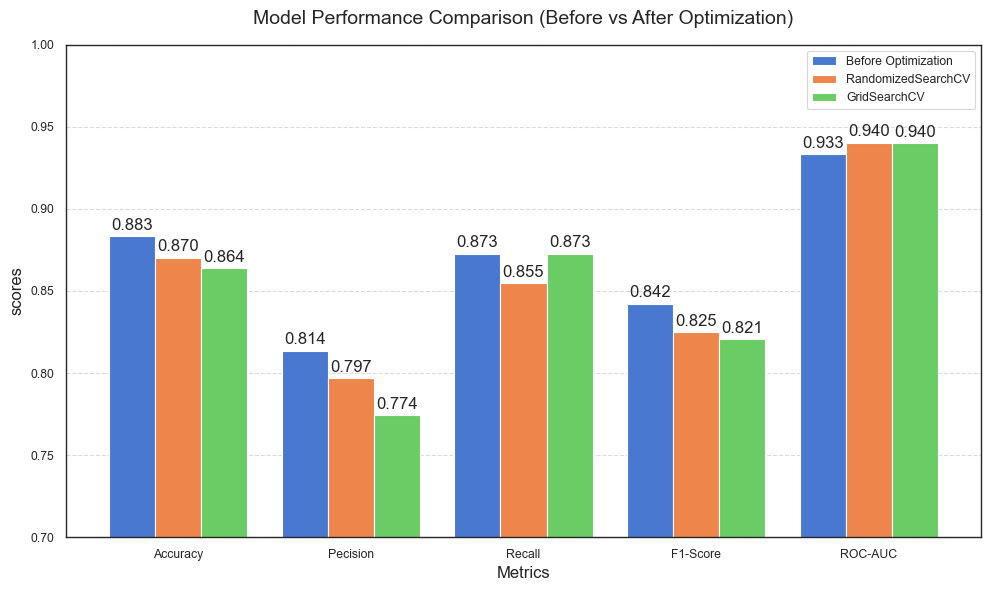

In [126]:
baseline = [0.8831, 0.8136,	0.8727,	0.8421,	0.9334]
random_tuned_rf_metrics = [0.8701, 0.7966,  0.8545, 0.8246, 0.9403]
grid_tuned_rf_metrics = [0.8636, 0.7742, 0.8727, 0.8205, 0.9398]
metrics = ['Accuracy', 'Pecision',  'Recall',  'F1-Score', 'ROC-AUC']


sns.set_theme(context='paper', style = 'white' )
ax =  comparison_table.plot(kind = "bar", figsize = (10,6), width = 0.8, color = sns.color_palette('muted', 3))

plt.title("Model Performance Comparison (Before vs After Optimization)", fontsize = 14, pad =15)
plt.xlabel("Metrics", fontsize = 12)
plt.ylabel('scores', fontsize = 12)
plt.xticks(rotation = 0)
plt.ylim(0.7,1.0)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.legend(loc = 'upper right')

# Display the values on top of each bar

for p in ax.patches:
    ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2.0,
            p.get_height()),
            ha = 'center',
            va = 'center',
            xytext = (0,8),
            textcoords = 'offset points',
            fontsize = 12)
    
plt.tight_layout()
plt.savefig('Model_perfomance_comparison.PNG')
plt.show()


## Model Performance Comparison (Before vs After Optimization)

This chart compares Random Forest performance across three 
states — baseline, RandomizedSearchCV tuned, and 
GridSearchCV tuned — across four evaluation metrics.

**Accuracy:**
The baseline (0.883) outperforms both tuned versions.
RandomizedSearchCV (0.870) and GridSearchCV (0.864) 
both show slight accuracy drops after tuning, which 
is acceptable since tuning prioritises generalisation 
over raw accuracy.

**Precision:**
All three versions drop in precision after tuning.
Baseline (0.814) leads, followed by RandomizedSearchCV 
(0.797) and GridSearchCV (0.774). This suggests both 
tuning methods introduced slightly more false positives.

**Recall:**
Baseline and RandomizedSearchCV both achieve 0.873, 
while GridSearchCV matches at 0.855. Recall is 
maintained well across all three — important for 
a medical dataset where missing diabetic patients 
is costly.

**F1-Score:**
Baseline (0.842) leads slightly over RandomizedSearchCV 
(0.825) and GridSearchCV (0.821) — consistent with 
the precision drop observed after tuning.

**ROC-AUC:**
Both tuning methods improved ROC-AUC from 0.933 
(baseline) to 0.940, confirming that despite slight 
drops in other metrics, both methods improved the 
model's overall ability to distinguish between 
diabetic and non-diabetic patients.

**Overall Conclusion:**
While tuning slightly reduced accuracy, precision 
and F1-Score, the ROC-AUC improvement to 0.940 
confirms better generalisation. RandomizedSearchCV 
is the preferred tuned model as it maintains higher 
recall (0.873) matching the baseline — critical 
for diabetes prediction where recall matters most.

## Feature Importance

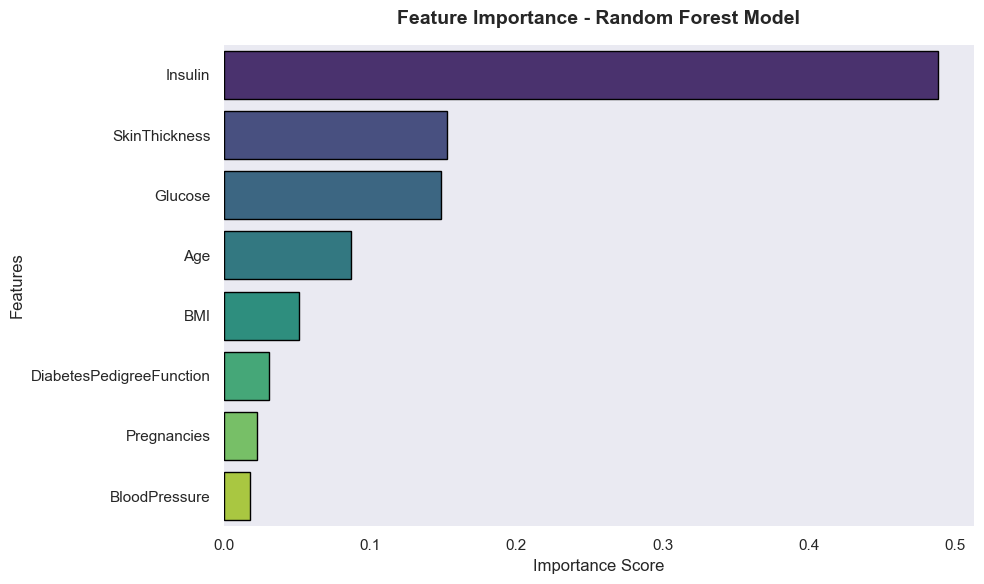

In [130]:
importances = random_tuned_rf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (10,6))
sns.set_theme(context='notebook', style = 'dark')
sns.barplot(x = 'Importance', y = 'Feature',hue = 'Feature', data = feature_imp_df, palette=  'viridis', legend = False,edgecolor = 'black')

plt.title("Feature Importance - Random Forest Model", fontsize = 14, pad = 15, fontweight = 'bold')
plt.xlabel("Importance Score", fontsize = 12)
plt.ylabel("Features", fontsize = 12)

sns.despine(left = True, bottom = True)
plt.tight_layout()
plt.savefig("Feature_importance.PNG")
plt.show()


## Feature Importance — Random Forest Model

The feature importance plot shows how much each feature 
contributed to the Random Forest model's predictions.

**Insulin (~0.50)** is the most important feature by 
a significant margin, suggesting that serum insulin 
levels are the strongest driver of diabetic predictions 
in this model. This is noteworthy given that Insulin 
had the most missing values in the raw dataset.

**SkinThickness and Glucose** follow closely as the 
second and third most important features, both scoring 
around 0.30. This aligns with medical understanding 
— glucose is a direct diabetes indicator while skin 
thickness reflects body fat and insulin resistance.

**Age (~0.15)** ranks fourth, confirming that older 
patients carry higher diabetes risk as observed in 
our earlier visualizations.

**BMI (~0.12)** ranks fifth despite being strongly 
linked to diabetes medically — suggesting that after 
imputation, its predictive signal may have weakened 
slightly.

**DiabetesPedigreeFunction, Pregnancies and 
BloodPressure** all score below 0.10, confirming 
they are the weakest predictors in this dataset 
which is consistent with our correlation heatmap 
findings.

**Key Takeaway:**
Insulin, SkinThickness and Glucose collectively 
dominate the model's decision making. This suggests 
future work could focus on improving data quality 
for these features — particularly Insulin — to 
further boost model performance.